# Project Venus – Color Extraction Spike
#
# Goal:
# Explore simple ways to extract dominant colors from a clothing image.
#
# Constraints:
# - Accuracy not critical
# - No model training
# - Prefer simple, explainable methods
#
# Done when:
# - Given one image, return ~3 dominant colors with rough percentages

In [1]:
# Minimal setup for color extraction spike

from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(264.5), np.float64(140.5), np.float64(-0.5))

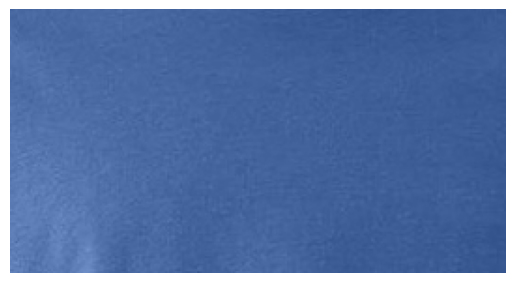

In [2]:
img = Image.open("shirt_crop.jpg")
plt.imshow(img)
plt.axis("off")


In [3]:
# --- Step 1: Ensure image is in RGB ---
# Some images can be RGBA or grayscale.
# We force RGB so every pixel is [R, G, B].
img_rgb = img.convert("RGB")

# --- Step 2: Resize the image ---
# We shrink the image to reduce computation.
# This does NOT change the dominant colors in a meaningful way.
# It just makes the algorithm faster and more stable.
img_small = img_rgb.resize((150, 150))

# --- Step 3: Convert image to numerical data ---
# Convert the image into a NumPy array:
# shape becomes (height, width, 3)
pixels = np.array(img_small)

# --- Step 4: Flatten the pixel grid ---
# KMeans expects a list of points, not a grid.
# We reshape into:
# (number_of_pixels, 3)
# Each row = one pixel [R, G, B]
pixels = pixels.reshape(-1, 3)

# --- Step 5: Run KMeans clustering ---
# We ask KMeans to find 3 clusters of colors.
# Each cluster represents a "dominant color".
kmeans = KMeans(
    n_clusters=3,
    random_state=42,  # ensures repeatable results
    n_init=10         # stability across runs
)

# Fit the model to the pixel data
kmeans.fit(pixels)

# --- Step 6: Extract dominant colors ---
# cluster_centers_ are the "average color" of each cluster
# These are the dominant colors in RGB form
colors = kmeans.cluster_centers_.astype(int)

# labels_ tells us which cluster each pixel belongs to
labels = kmeans.labels_

# --- Step 7: Calculate color percentages ---
# Count how many pixels belong to each cluster
counts = np.bincount(labels)

# Convert counts into percentages
percentages = counts / counts.sum()

# --- Final Output ---
# Pair each dominant color with its percentage
list(zip(colors, percentages))


[(array([ 61,  93, 150]), np.float64(0.4881333333333333)),
 (array([ 87, 119, 176]), np.float64(0.12626666666666667)),
 (array([ 71, 103, 160]), np.float64(0.3856))]

In [4]:
# Calculate brightness for each cluster color
brightness = (0.2126*colors[:,0] + 0.7152*colors[:,1] + 0.0722*colors[:,2])

# Find indices sorted by brightness (dark -> light)
order = np.argsort(brightness)

# Middle brightness cluster index
mid_idx = order[1]

# "Main fabric tone" = the middle-brightness cluster
main_color = colors[mid_idx]
main_pct = percentages[mid_idx]

main_color, main_pct


(array([ 71, 103, 160]), np.float64(0.3856))